# 02 · 2D maps, 3D surfaces, and access

**Decision question.** How does representation change our understanding of access, and which assumptions drive an access estimate?

**Time:** 30–45 minutes. **Prerequisites:** basic Python arrays and tables. Run cells from top to bottom.
The shared `rewiring.py` module must stay beside the notebooks. Initial package downloads require internet;
the core calculations use reproducible synthetic data. No health-service credentials are needed.

**Data contract:** the fictional grid is geographically anchored near Gaborone for teaching map coordinates.
Its people, facilities, climate, events, and model parameters are invented. It is **not a map of actual
Gaborone disease, vulnerability, buildings, or care access**. Satellite catalog metadata, when used, is labeled separately.

[Book](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/) · [Interactive demo gallery](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/demos/) · [Data and credits](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/DATA_SOURCES.md)

In [1]:
import sys
if sys.platform == 'emscripten':
    import micropip
    await micropip.install(['numpy', 'pandas', 'matplotlib', 'folium==0.20.0', 'plotly'])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, IFrame
from rewiring import (city, long_table, map_image, map_matrix, geojson,
                      leaflet, save_export, simulate_twin, teaching_review, HATS, SITE, LABEL, EXTENT)
plt.rcParams.update({'figure.dpi': 105, 'axes.spines.top': False, 'axes.spines.right': False})
cells, cube = city()
panel = long_table(cells, cube)
print(LABEL)
print('Python', sys.version.split()[0], '| cells:', len(cells), '| monthly observations:', len(panel))

SYNTHETIC teaching data · not observations or a forecast
Python 3.13.14 | cells: 64 | monthly observations: 1536


## Start with an accessible 2D view

Our access variable assumes straight-line walking at 4 km/h to one of two fictional facilities, plus
five minutes of overhead. It omits roads, rivers, opening hours, fees, disability, and travel mode.
Coordinates are longitude/latitude; conversion to kilometers is a local approximation. Do not measure
Euclidean distance directly in degrees or treat these contours as real catchments.

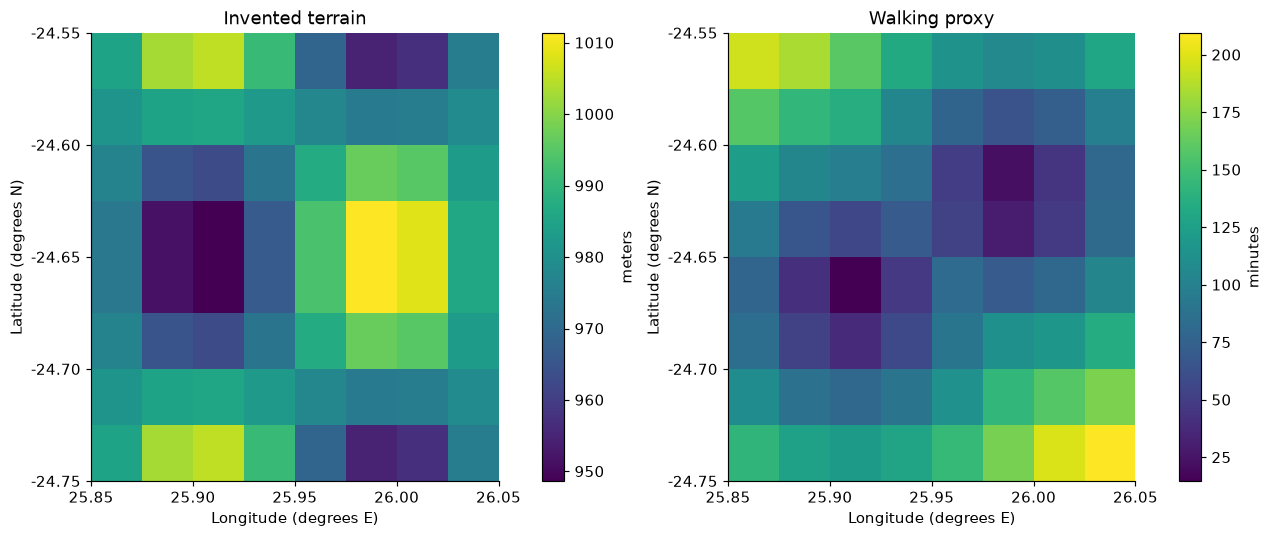

In [2]:
terrain = cells.elevation_m.to_numpy().reshape(8,8)
access = cells.access_min.to_numpy().reshape(8,8)
fig, axes = plt.subplots(1,2,figsize=(12,5),layout='constrained')
for ax,z,title,unit in zip(axes,[terrain,access],['Invented terrain','Walking proxy'],['meters','minutes']):
    im=map_image(ax,z,title); fig.colorbar(im,ax=ax,label=unit)
plt.show()

## Maps should support inspection

Hover to inspect the cell ID, value, population, and synthetic status. This Leaflet view intentionally
has no external basemap tiles; the graticule and coordinates are sufficient for the lesson. The map
library loads from a CDN, so a static plot above remains available without that dependency.

In [3]:
display(leaflet(cells, access, 'access_min'))

## A surface is one possible view of a variable

The vertical axis below represents invented elevation in meters. Color and perspective cannot establish
data quality. A surface between grid centers interpolates visually; no additional observations are created.

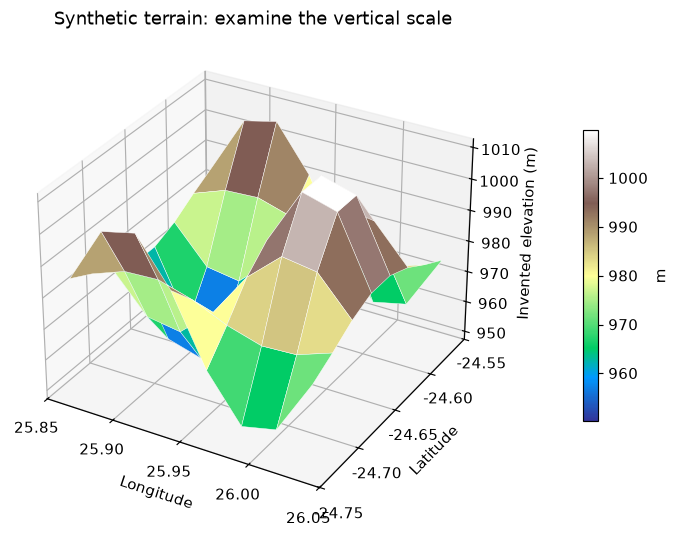

In [4]:
lon=cells.lon.to_numpy().reshape(8,8); lat=cells.lat.to_numpy().reshape(8,8)
fig=plt.figure(figsize=(9,6)); ax=fig.add_subplot(projection='3d')
surface=ax.plot_surface(lon,lat,terrain,cmap='terrain',edgecolor='white',linewidth=.3)
ax.set(xlabel='Longitude',ylabel='Latitude',zlabel='Invented elevation (m)',title='Synthetic terrain: examine the vertical scale')
ax.ticklabel_format(useOffset=False)
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
for axis in [ax.xaxis,ax.yaxis]:
    axis.set_major_locator(MaxNLocator(4)); axis.set_major_formatter(FormatStrFormatter('%.2f'))
fig.colorbar(surface,ax=ax,shrink=.6,label='m',pad=.12); plt.show()

In [5]:
import plotly.graph_objects as go
interactive = go.Figure(go.Surface(x=lon,y=lat,z=terrain,colorscale='Earth'))
interactive.update_layout(title='Orbit the synthetic terrain',height=470,
    scene=dict(xaxis_title='Longitude',yaxis_title='Latitude',zaxis_title='Elevation (m)'))
display(HTML(interactive.to_html(full_html=False, include_plotlyjs='cdn')))

## Sensitivity belongs beside the map

Recompute travel time under 3, 4, and 5 km/h walking assumptions. Keep the five-minute overhead fixed.
Report a population-weighted accessibility measure, rather than the fraction of equally sized grid cells.
A 30-minute threshold here is an exercise parameter, not a recommended service standard.

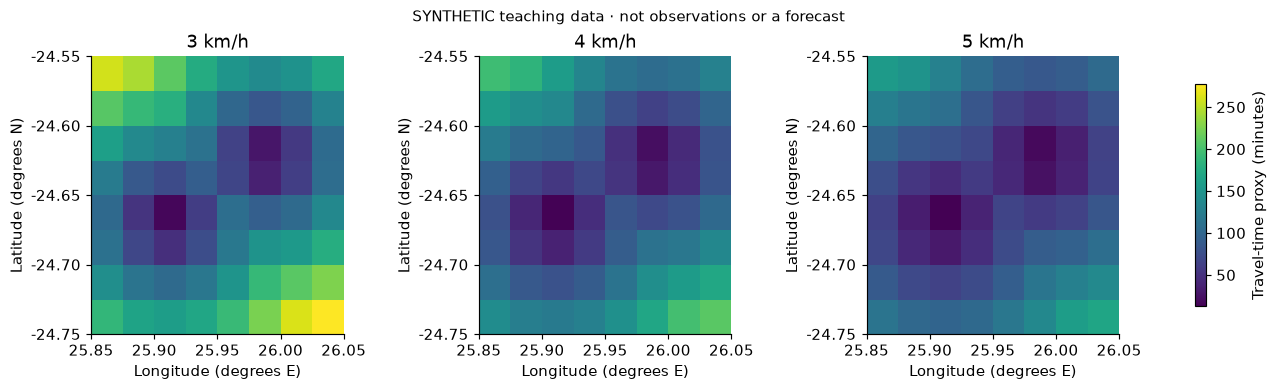

,speed_kmh,population_share_within_30min
0,3,0.037243
1,4,0.047912
2,5,0.047912


In [6]:
speeds = [3,4,5]
scenarios = [5 + (access-5)*4/speed for speed in speeds]
map_matrix(scenarios,[f'{s} km/h' for s in speeds],'Travel-time proxy (minutes)')
plt.show()
shares=[np.average(z.ravel()<=30,weights=cells.population) for z in scenarios]
display(pd.DataFrame({'speed_kmh':speeds,'population_share_within_30min':shares}))

## Investigate, interpret, and discuss

1. Compare cell-weighted and population-weighted coverage. Explain the difference.
2. Simulate a 15-minute service delay in the eastern half and redraw the access map.
3. List the evidence needed for actual travel-time routing and an inclusive access assessment.

**Before sharing:** state the decision, data status, units, denominator, scale, uncertainty, and who can contest the result.
Record what would change your conclusion. Export only information that the intended audience needs.

## Sources and attribution

- Tobias (2013), supplied presentation, service availability and delivery examples, pp. 27–28.
- [Folium documentation](https://python-visualization.github.io/folium/latest/) and [Plotly 3D surfaces](https://plotly.com/python/3d-surface-plots/).
- All terrain, population, and facilities in this exercise are generated by `rewiring.py`.

Original lesson code: MIT. Original narrative, synthetic data, and generated figures: CC BY 4.0.
Third-party data, videos, services, and software retain their own terms.
[Full references](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/REFERENCES.md) · [Third-party notices](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/THIRD_PARTY_NOTICES.md).